## Plant Pathology

This project classifies photos of apple tree leaves into one of four categories: healthy, showing multiple diseases, showing rust, or showing scab. It is the only true image (CNN) project among these 20 competitions, using real leaf photographs instead of pre-extracted features.

## Approach
1. Load the data and view example images from each category
2. Load and resize the images, and split into train/validation
3. Train a small CNN (or a lightweight pretrained model) and evaluate mean AUC
4. Generate probabilities and create the submission file
5. Submit to Kaggle and record the score

In [1]:
import os
from getpass import getpass

os.environ["KAGGLE_API_TOKEN"] = getpass("Paste your Kaggle API token and press Enter: ")

!pip install -q -U kaggle
!kaggle competitions download -c plant-pathology-2020-fgvc7
!unzip -oq plant-pathology-2020-fgvc7.zip

Paste your Kaggle API token and press Enter: ··········
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.2 MB/s eta 0:00:00
100% 779M/779M [00:10<00:00, 75.2MB/s]



In [16]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   image_id           1821 non-null   object
 1   healthy            1821 non-null   int64 
 2   multiple_diseases  1821 non-null   int64 
 3   rust               1821 non-null   int64 
 4   scab               1821 non-null   int64 
dtypes: int64(4), object(1)
memory usage: 71.3+ KB


In [18]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1821 entries, 0 to 1820
Data columns (total 1 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  1821 non-null   object
dtypes: object(1)
memory usage: 14.4+ KB


In [19]:
train.sample(1)

,image_id,healthy,multiple_diseases,rust,scab
1193,Train_1193,1,0,0,0


In [20]:
test.sample(1)

,image_id
1473,Test_1473


In [21]:
train.shape, test.shape

((1821, 5), (1821, 1))

In [22]:
train.head(3)

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0


In [23]:
train[["healthy", "multiple_diseases", "rust", "scab"]].sum()

,0
healthy,516
multiple_diseases,91
rust,622
scab,592


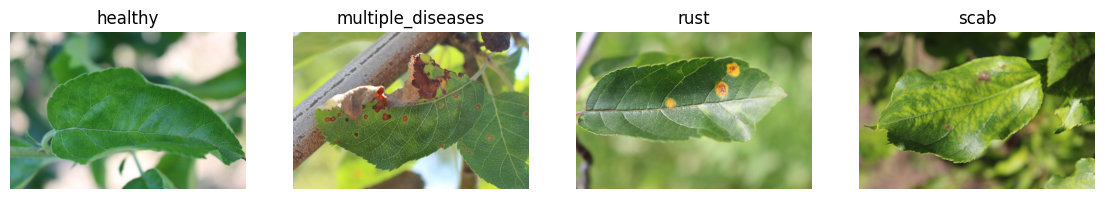

In [24]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cat in zip(axes, ["healthy", "multiple_diseases", "rust", "scab"]):
    row = train[train[cat] == 1].iloc[0]
    img = mpimg.imread(f"images/{row['image_id']}.jpg")
    ax.imshow(img)
    ax.set_title(cat)
    ax.axis("off")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

IMG_SIZE = 224

x = np.array([img_to_array(load_img(f"images/{img_id}.jpg", target_size=(IMG_SIZE, IMG_SIZE))) for img_id in train["image_id"]])
y = train[["healthy", "multiple_diseases", "rust", "scab"]].values

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
x.shape, y.shape

((1821, 224, 224, 3), (1821, 4))

In [27]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Lambda(preprocess_input),
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(4, activation="softmax"),
])

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [29]:
early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
history = model.fit(x_train, y_train, validation_data=(x_val, y_val), epochs=20, batch_size=32, callbacks=[early_stop])

Epoch 1/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 33s 428ms/step - accuracy: 0.6731 - loss: 0.8699 - val_accuracy: 0.8356 - val_loss: 0.4947
Epoch 2/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.8317 - loss: 0.4882 - val_accuracy: 0.8493 - val_loss: 0.4581
Epoch 3/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.8565 - loss: 0.4009 - val_accuracy: 0.8795 - val_loss: 0.3704
Epoch 4/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.8867 - loss: 0.3262 - val_accuracy: 0.8767 - val_loss: 0.3432
Epoch 5/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.8990 - loss: 0.2927 - val_accuracy: 0.8795 - val_loss: 0.3432
Epoch 6/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.9245 - loss: 0.2209 - val_accuracy: 0.8767 - val_loss: 0.3587
Epoch 7/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 115ms/step - accuracy: 0.9334 - loss: 0.1982 - val_accuracy: 0.8767 - val_loss: 0.3508
Epoch 8/20
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.9382 - loss: 0.1772 - val_accuracy: 0

In [30]:
from sklearn.metrics import roc_auc_score

proba_val = model.predict(x_val)
print("Validation mean AUC:", round(roc_auc_score(y_val, proba_val, average="macro"), 4))

12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 466ms/step
Validation mean AUC: 0.9775


In [31]:
x_test = np.array([img_to_array(load_img(f"images/{img_id}.jpg", target_size=(224, 224))) for img_id in test["image_id"]])

proba_test = model.predict(x_test)

submission = pd.DataFrame(proba_test, columns=["healthy", "multiple_diseases", "rust", "scab"])
submission.insert(0, "image_id", test["image_id"])
submission.to_csv("submission.csv", index=False)

57/57 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step


In [32]:
!kaggle competitions submit -c plant-pathology-2020-fgvc7 -f submission.csv -m "ResNet50 transfer learning"

100% 103k/103k [00:00<00:00, 142kB/s]
99 submissions remaining today.
Successfully submitted to Plant Pathology 2020 - FGVC7

In [33]:
model.save("plant_model.keras")